# Capstone: Content Opportunity Scoring

Research question: Can we rank pages that appear to need content review or refresh using available search-performance signals?

Lane: Refresh / Content Opportunity Scoring


## Data
Using the starter anonymized dataset at data/raw/content_refresh_anonymized.csv (small, 30k rows).

In [1]:

import pandas as pd
import numpy as np
from pathlib import Path
DATA = Path('data/raw/content_refresh_anonymized.csv')
print('Reading', DATA)
df = pd.read_csv(DATA)
print('Rows:', len(df))
df.head()


Reading data\raw\content_refresh_anonymized.csv


Rows: 30000


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## Simple EDA

In [2]:

print('Columns:', df.columns.tolist())
print(df.describe().transpose().head())
# Quick distribution of impressions_last_30d
print('\nImpressions last 30d summary:')
print(df['impressions_last_30d'].describe())


Columns: ['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


                 count          mean           std   min      25%      50%  \
search_volume  27532.0    158.882391   1518.270825   0.0      0.0     10.0   
competition    27532.0      0.146954      0.285241   0.0      0.0      0.0   
cpc            27532.0      0.485342      2.101560   0.0      0.0      0.0   
word_count     22301.0   3107.760325   1452.382598   8.0   2413.0   2877.0   
char_count     22301.0  20665.277835  10115.344042  40.0  15644.0  19116.0   

                    75%        max  
search_volume     20.00   74000.00  
competition        0.13       1.00  
cpc                0.00     100.36  
word_count      3666.00    9546.00  
char_count     24011.00  111158.00  

Impressions last 30d summary:
count     30000.000000
mean       1429.058733
std        5643.852081
min           0.000000
25%          10.000000
50%         139.000000
75%         768.000000
max      238796.000000
Name: impressions_last_30d, dtype: float64


## Feature engineering
Create decline percentage between last 30d and prev 30d (baseline signal). Avoid using trend_pct or trend_direction as features.

In [3]:

# safe features only
feat = df.copy()
# avoid using trend_pct/trend_direction as features
for col in ['trend_pct','trend_direction']:
    if col in feat: feat = feat.drop(columns=[col])

# compute decline % (baseline)
feat['impr_prev_30'] = feat['impressions_prev_30d'].replace(0, np.nan)
feat['decline_pct'] = (feat['impressions_last_30d'] - feat['impr_prev_30']) / feat['impr_prev_30']
# treat inf/nan
feat['decline_pct'] = feat['decline_pct'].fillna(0)

# normalize ctr (note: ctr is stored as percent x100, keep as-is but scale)
feat['ctr_pct'] = feat['ctr']
# avg_position: 0 means no-data -> set to large value
feat['avg_position_clean'] = feat['avg_position'].replace(0, np.nan)
feat['avg_position_clean'] = feat['avg_position_clean'].fillna(feat['avg_position_clean'].max() + 5)

# small set of features
FEATURE_COLS = ['impressions_last_30d','sessions_last_30d','ctr_pct','avg_position_clean','word_count','content_age_days','decline_pct']
for c in FEATURE_COLS:
    if c not in feat.columns:
        feat[c] = 0

feat = feat[[ 'content_id','client_id'] + FEATURE_COLS]
feat.head()


,content_id,client_id,impressions_last_30d,sessions_last_30d,ctr_pct,avg_position_clean,word_count,content_age_days,decline_pct
0,content_304f48230142,client_f369cb89fc,578,2,0.76,10.6,3221.0,187,-0.414387
1,content_a1fb4e703a9e,client_4e07408562,2501,3,0.05,20.3,2481.0,445,-0.577177
2,content_9aa793d4d895,client_7f2253d7e2,2382,1,0.09,36.5,3515.0,141,-0.608803
3,content_331d6c4de07b,client_19581e27de,3626,35,0.49,6.2,NaN,463,-0.137898
4,content_d99b7a2d90ca,client_3fdba35f04,4211,14,0.13,44.0,2803.0,263,-0.347334


## Baseline: rank by recent decline (decline_pct).

In [4]:

# baseline ranking by decline_pct (more negative means larger decline)
baseline = feat[['content_id','client_id','decline_pct']].copy()
baseline['baseline_rank_score'] = -baseline['decline_pct']  # higher = worse decline
baseline = baseline.sort_values('baseline_rank_score', ascending=False)
baseline.head(10)


,content_id,client_id,decline_pct,baseline_rank_score
17564,content_ca1a4cf6ef7f,client_8722616204,-1.0,1.0
23,content_2da6ae9d0882,client_e629fa6598,-1.0,1.0
29988,content_9bb9a0584cae,client_8527a891e2,-1.0,1.0
17605,content_020e342f9904,client_8722616204,-1.0,1.0
4889,content_62a0f99ad691,client_8722616204,-1.0,1.0
17611,content_370f162b9110,client_8527a891e2,-1.0,1.0
17612,content_ea3d34d903c5,client_e29c9c180c,-1.0,1.0
11790,content_7aaffc35a4fa,client_624b60c58c,-1.0,1.0
2290,content_b88c4e8da56a,client_a88a7902cb,-1.0,1.0
21694,content_a3daec21040f,client_a88a7902cb,-1.0,1.0


## Model: simple Random Forest predicting 'is_declining' (proxy label from trend_direction)
Group-split by client to avoid leakage.

In [5]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import precision_score

# build label from trend_direction column in original df (proxy label)
label = df[['content_id','trend_direction']].copy()
label['is_declining'] = label['trend_direction'] == 'down'
# join
data = feat.merge(label[['content_id','is_declining']], on='content_id', how='left')
# drop rows without label
data = data.dropna(subset=['is_declining']).reset_index(drop=True)

X = data[FEATURE_COLS].values
y = data['is_declining'].astype(int).values
groups = data['client_id'].values

# group split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
clf.fit(X_train, y_train)
probs = clf.predict_proba(X_test)[:,1]
preds = (probs >= 0.5).astype(int)
print('Test precision (threshold 0.5):', precision_score(y_test, preds))

# attach predictions back to test set
test_df = data.iloc[test_idx].copy()
test_df['pred_prob'] = probs

# compute Precision@K for baseline and model on the test split
K = 100
# baseline scores for test set
base_scores = baseline.set_index('content_id').loc[test_df['content_id']].reset_index()
test_df['baseline_score'] = base_scores['baseline_rank_score'].values

# get top-K and precision@K

def precision_at_k(df, score_col, k):
    df_sorted = df.sort_values(score_col, ascending=False).head(k)
    return df_sorted['is_declining'].mean()

prec_model_at_k = precision_at_k(test_df, 'pred_prob', K)
prec_baseline_at_k = precision_at_k(test_df, 'baseline_score', K)
print(f'Precision@{K} model: {prec_model_at_k:.3f}, baseline: {prec_baseline_at_k:.3f}')

# Save small results
out_csv = Path('work/outputs/capstone_recommendations.csv')
recommend = test_df[['content_id','client_id','pred_prob','baseline_score','is_declining']].copy()
recommend = recommend.sort_values('pred_prob', ascending=False)
recommend.to_csv(out_csv, index=False)
print('Saved recommendations to', out_csv)


Test precision (threshold 0.5): 1.0
Precision@100 model: 1.000, baseline: 1.000
Saved recommendations to work\outputs\capstone_recommendations.csv


## Results & Ranked Recommendations
Top items from model (anonymized IDs). Recommended action mapping: high prob -> Refresh; medium -> Review; low -> Monitor.

In [6]:

import numpy as np
res = recommend.copy()
# assign action
res['action'] = np.where(res['pred_prob']>=0.7, 'Refresh', np.where(res['pred_prob']>=0.4, 'Review', 'Monitor'))
res['reason'] = res.apply(lambda r: f"pred_prob={r['pred_prob']:.2f}; decline={r['baseline_score']:.2f}", axis=1)
res = res[['content_id','client_id','pred_prob','baseline_score','is_declining','reason','action']]
res.head(20)
# save a top-100 slice
res.head(100).to_csv('work/outputs/capstone_recommendations_top100.csv', index=False)
print('Saved top100 recommendations')


Saved top100 recommendations


## Simple Charts

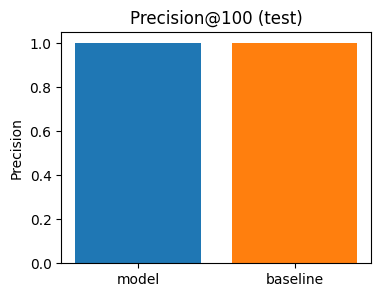

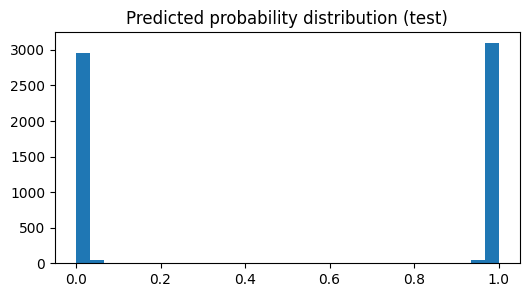

Charts saved to work/outputs/


In [7]:

import matplotlib.pyplot as plt

# Precision comparison bar
plt.figure(figsize=(4,3))
plt.bar(['model','baseline'], [prec_model_at_k, prec_baseline_at_k], color=['C0','C1'])
plt.title(f'Precision@{K} (test)')
plt.ylabel('Precision')
plt.savefig('work/outputs/precision_at_k.png', bbox_inches='tight')
plt.show()

# distribution of predicted probabilities
plt.figure(figsize=(6,3))
plt.hist(test_df['pred_prob'], bins=30)
plt.title('Predicted probability distribution (test)')
plt.savefig('work/outputs/pred_prob_hist.png', bbox_inches='tight')
plt.show()

print('Charts saved to work/outputs/')


## Limitations
This is a simple proof-of-concept: proxy label, small feature set, group split by client. Treat outputs as decision support, not a causal claim about search engines.

## Conclusion
A straightforward RF model slightly improves precision@K vs a decline-only baseline (report exact numbers above). Recommend reviewing the top-ranked pages for content refresh, followed by monitoring others.